# Healthcare Accessibility Index — Current State vs. AI Platform Scenario
### AI Regional Healthcare Coordination Platform · United States (50 states)

Recreation of the South Korea accessibility-index analysis for the **50 U.S. states**
(District of Columbia excluded from the index as an outlier — see Step 1). The notebook
builds a 0–1 Healthcare Accessibility Index from official statistics, projects the
improvement under the proposed AI coordination platform, and renders both as choropleth
maps on a shared color scale.

U.S. context: 17.7% of Americans are 65+ (2023 ACS) and the share is projected to reach
20.6% by 2030 — the entire country is approaching the super-aged threshold Korea crossed
in 2025. The same "aging + regional decline + workforce shortage" triad concentrates in
rural states: HRSA designates most of the Mountain West and Deep South as Health
Professional Shortage Areas. The platform's modules translate directly: AI triage aligned
with the **Emergency Severity Index (ESI, 5 levels)** used by U.S. EDs, capacity-aware
routing across health systems and regional EMS networks (911 dispatch integration in
place of Korea's 119), and an interoperable EMR layer riding the **TEFCA / QHIN**
national exchange framework in place of Korea's HIRA-linked EMR exchange.

**Pipeline** (identical to the Korea notebook)

| Step | What happens | Method |
|---|---|---|
| 1 | Data assembly | 2 indicators per state, from official sources (referenced below) |
| 2 | Need adjustment | supply ÷ relative elderly burden |
| 3 | Normalization | min-max scaling → 0–1 index |
| 4 | Scenario projection | proportional gap-closure model (30%) |
| 5 | Map geometry | SVG state boundaries → matplotlib paths |
| 6 | Visualization | two choropleths, shared RdYlGn scale |
| 7 | Verification & export | ranking cross-check, sensitivity, CSV |

**Requirements**
```
pip install numpy pandas matplotlib svgpath2mpl
npm install @svg-maps/usa            # map boundary geometry (MIT license)
```

## Step 1 — Data assembly (with references)

Two indicators per state — **both columns are exact, text-verified values** (no
estimation flags needed in this recreation):

| Column | Definition | Year | Source |
|---|---|---|---|
| `doctors_per_1k` | Active physicians per 1,000 population (AAMC reports per 100,000; divided by 100 here) | 2022 | AAMC U.S. Physician Workforce Data Dashboard, full 51-unit ranking as published by Becker's Hospital Review, Nov 20 2023, https://www.beckershospitalreview.com/quality/hospital-physician-relationships/active-physicians-per-100-000-people-ranked-by-state/ |
| `pct_65plus` | Share of population aged 65+ (%) | 2020 | U.S. Census Bureau, Vintage 2020 Population Estimates, full ranked table via Population Reference Bureau, https://www.prb.org/news/which-us-states-are-the-oldest/ |

**Why DC is excluded from the index:** the District has 925.7 active physicians per
100,000 — 1.9× Massachusetts, the highest state — because it is a city-scale
jurisdiction hosting the physician workforce of a multi-state metro area. Including it
would compress all 50 states into the bottom quarter of the min-max scale. It is drawn
in neutral grey on the maps, exactly as the China recreation handles Hong Kong / Macau.

**Independent cross-check** (rank validation): AAMC 2024 key findings — Massachusetts
highest, Idaho/Mississippi lowest for active physicians per capita (same ordering as the
2022 dashboard column used here); Census/ACS 2023 — Maine oldest (22.9%), Utah youngest
(12.2%), national 17.7%, same ordering as the 2020 vintage shares used here.

In [1]:
%matplotlib inline
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import PathPatch
from matplotlib.colors import Normalize
from matplotlib import cm
from svgpath2mpl import parse_path

NATIONAL_AGED = 16.8   # national 65+ share (%), 2020 Census (55.8M of 331.4M)
GAP_CLOSURE   = 0.30   # Step 4 scenario assumption (platform closes 30% of each gap)

# key = state id used in the SVG boundary file (USPS abbreviation, lowercase)
DATA = {
    #  key   name              doc/1k  65+%
    "al": ("Alabama",          2.244,  17.8),
    "ak": ("Alaska",           2.934,  13.1),
    "az": ("Arizona",          2.574,  18.5),
    "ar": ("Arkansas",         2.246,  17.7),
    "ca": ("California",       3.036,  15.2),
    "co": ("Colorado",         3.064,  15.1),
    "ct": ("Connecticut",      3.786,  18.2),
    "de": ("Delaware",         2.994,  20.0),
    "fl": ("Florida",          2.796,  21.3),
    "ga": ("Georgia",          2.411,  14.7),
    "hi": ("Hawaii",           3.188,  19.6),
    "id": ("Idaho",            1.920,  16.7),
    "il": ("Illinois",         3.040,  16.6),
    "in": ("Indiana",          2.401,  16.5),
    "ia": ("Iowa",             2.275,  17.9),
    "ks": ("Kansas",           2.408,  16.8),
    "ky": ("Kentucky",         2.426,  17.2),
    "la": ("Louisiana",        2.840,  16.4),
    "me": ("Maine",            3.307,  21.8),
    "md": ("Maryland",         3.977,  16.3),
    "ma": ("Massachusetts",    4.802,  17.4),
    "mi": ("Michigan",         3.078,  18.2),
    "mn": ("Minnesota",        3.232,  16.8),
    "ms": ("Mississippi",      2.037,  16.9),
    "mo": ("Missouri",         3.112,  17.7),
    "mt": ("Montana",          2.625,  19.7),
    "ne": ("Nebraska",         2.538,  16.5),
    "nv": ("Nevada",           2.178,  16.5),
    "nh": ("New Hampshire",    3.241,  19.3),
    "nj": ("New Jersey",       3.055,  17.0),
    "nm": ("New Mexico",       2.570,  18.5),
    "ny": ("New York",         3.982,  17.4),
    "nc": ("North Carolina",   2.714,  17.1),
    "nd": ("North Dakota",     2.465,  16.1),
    "oh": ("Ohio",             3.127,  17.9),
    "ok": ("Oklahoma",         2.104,  16.4),
    "or": ("Oregon",           3.165,  18.6),
    "pa": ("Pennsylvania",     3.372,  19.1),
    "ri": ("Rhode Island",     3.751,  18.2),
    "sc": ("South Carolina",   2.445,  18.7),
    "sd": ("South Dakota",     2.515,  17.6),
    "tn": ("Tennessee",        2.611,  17.1),
    "tx": ("Texas",            2.351,  13.2),
    "ut": ("Utah",             2.311,  11.7),
    "vt": ("Vermont",          3.899,  20.6),
    "va": ("Virginia",         2.754,  16.3),
    "wa": ("Washington",       2.925,  16.2),
    "wv": ("West Virginia",    2.867,  20.9),
    "wi": ("Wisconsin",        2.844,  18.0),
    "wy": ("Wyoming",          2.176,  17.8),
}
DC_NOTE = ("dc", "District of Columbia", 9.257, 13.0)   # excluded outlier, drawn grey

df = pd.DataFrame(
    [(k, *v) for k, v in DATA.items()],
    columns=["key", "region", "doctors_per_1k", "pct_65plus"],
).set_index("key")
df.head(10)

,region,doctors_per_1k,pct_65plus
key,,,
al,Alabama,2.244,17.8
ak,Alaska,2.934,13.1
az,Arizona,2.574,18.5
ar,Arkansas,2.246,17.7
ca,California,3.036,15.2
co,Colorado,3.064,15.1
ct,Connecticut,3.786,18.2
de,Delaware,2.994,20.0
fl,Florida,2.796,21.3


## Step 2 — Need adjustment (the "per capita effect")

Raw physician density ignores *who* the population is: 1,000 residents of Florida
(21.3% elderly) generate far more care demand than 1,000 residents of Utah (11.7%
elderly, the youngest state). Each state's supply is therefore deflated by its
**relative elderly burden**:

$$S_i = \frac{\text{doctors}_i}{\;\text{aged}_i / \text{aged}_{\text{national}}\;}$$

- A state with the national age structure keeps its raw density (denominator = 1).
- Florida: 2.80 → **2.21** effective supply (burden ratio 1.27 — the retirement-magnet effect).
- Utah: 2.31 → **3.32** (burden ratio 0.70 — young state, low per-capita need).

This is the simplest member of the *need-adjusted supply ratio* family used in
health-workforce research — transparent, and every input is citable. The resulting
bottom group (Idaho, Mississippi, Wyoming, Alabama, Arkansas, Iowa, Oklahoma) closely
tracks HRSA's rural Health Professional Shortage Area designations.

In [2]:
df["need_ratio"]  = df["pct_65plus"] / NATIONAL_AGED
df["need_adj_supply"] = df["doctors_per_1k"] / df["need_ratio"]
df.sort_values("need_adj_supply")[["region", "doctors_per_1k", "pct_65plus",
                                   "need_ratio", "need_adj_supply"]].round(3)

,region,doctors_per_1k,pct_65plus,need_ratio,need_adj_supply
key,,,,,
id,Idaho,1.920,16.7,0.994,1.931
ms,Mississippi,2.037,16.9,1.006,2.025
wy,Wyoming,2.176,17.8,1.060,2.054
al,Alabama,2.244,17.8,1.060,2.118
ar,Arkansas,2.246,17.7,1.054,2.132
ia,Iowa,2.275,17.9,1.065,2.135
ok,Oklahoma,2.104,16.4,0.976,2.155
sc,South Carolina,2.445,18.7,1.113,2.197
fl,Florida,2.796,21.3,1.268,2.205


## Step 3 — Normalization to the 0–1 index

Min-max scaling turns need-adjusted supply into the benchmark index:

$$\text{Index}_i = \frac{S_i - S_{\min}}{S_{\max} - S_{\min}}$$

Interpretation caveats:
- The index is **relative within the 50 states, within this data vintage** — 0 = lowest
  need-adjusted supply (Idaho), 1 = highest (Massachusetts). It does **not** mean "no access."
- Two headline movements versus raw density: **Florida drops sharply** once its
  retirement-age burden is priced in, and young **Utah, Texas and Alaska rise** — the
  same demographic mechanism as Sejong in the Korea analysis. Geographic barriers
  (distance-to-care in Alaska or Montana) are *not* captured by a per-capita index;
  they are what Module B routing and Module D telemedicine target.

In [3]:
smin, smax = df["need_adj_supply"].min(), df["need_adj_supply"].max()
df["index_current"] = (df["need_adj_supply"] - smin) / (smax - smin)
df.sort_values("index_current", ascending=False)[["region", "index_current"]].round(2)

,region,index_current
key,,
ma,Massachusetts,1.00
md,Maryland,0.80
ny,New York,0.71
ak,Alaska,0.68
ct,Connecticut,0.58
ri,Rhode Island,0.57
co,Colorado,0.55
ca,California,0.53
ut,Utah,0.51


## Step 4 — Platform scenario projection

**Proportional gap-closure model:**

$$\text{Index}^{proj}_i = \text{Index}_i + \gamma\,(1 - \text{Index}_i), \qquad \gamma = 0.30$$

The platform adds no physicians; it raises *effective* accessibility through
coordination — **Module A** (AI triage on the ESI scale) removes non-urgent demand from
scarce ED capacity (CDC: roughly half of U.S. ED visits are non-urgent), **Module B**
(capacity-aware routing) reallocates patients across hospital systems and EMS regions,
and **Module D** (telemedicine for ESI-4/5 cases) substitutes remote care where supply
is thin — the mechanism CMS expanded permanently after the pandemic.

Because the uplift is proportional to the gap, underserved states improve most
(Idaho 0.00 → 0.30; Mississippi 0.04 → 0.33) while Massachusetts stays at 1.00 —
the platform's regional-equity mechanism in one line of algebra.

**Academic honesty:** γ = 0.30 is a *scenario assumption, not an estimate* — consistent
with the "modelled estimates; prospective validation required" framing in the project's
Integrated Narrative. Sensitivity at γ = 0.15 / 0.30 / 0.45 is run in Step 7.

In [4]:
df["index_projected"] = df["index_current"] + GAP_CLOSURE * (1 - df["index_current"])
df["gain"] = df["index_projected"] - df["index_current"]
df.sort_values("index_current")[["region", "index_current",
                                 "index_projected", "gain"]].round(2)

,region,index_current,index_projected,gain
key,,,,
id,Idaho,0.00,0.30,0.30
ms,Mississippi,0.03,0.32,0.29
wy,Wyoming,0.05,0.33,0.29
al,Alabama,0.07,0.35,0.28
ar,Arkansas,0.07,0.35,0.28
ia,Iowa,0.08,0.35,0.28
ok,Oklahoma,0.08,0.36,0.28
sc,South Carolina,0.10,0.37,0.27
fl,Florida,0.10,0.37,0.27


## Step 5 — Map geometry

Boundary shapes come from the npm package **`@svg-maps/usa`** v2.0.0 (MIT license,
https://www.npmjs.com/package/@svg-maps/usa) — 50 states + DC as SVG paths whose `id`s
are lowercase USPS abbreviations, matching the `DATA` keys (Alaska and Hawaii are drawn
as insets by the package). DC is drawn in neutral grey with no index value.

Label anchors are polygon centroids (shoelace formula) computed on each state's
**largest ring**, so offshore islands don't drag the anchor into the sea. Labels use
USPS abbreviations (50 units would clutter full names), and the small Northeastern
states get manual leader-line offsets into the Atlantic.

In [5]:
SVG_FILE = "node_modules/@svg-maps/usa/usa.svg"
NO_DATA  = ["dc"]      # excluded outlier (see Step 1), drawn grey

svg = open(SVG_FILE).read()
paths = {}
for m in re.finditer(r'<path\s+id="(.*?)"[^>]*?\sd="(.*?)"', svg, re.S):
    paths[m.group(1)] = parse_path(m.group(2))
assert set(paths) == set(DATA) | set(NO_DATA), "SVG regions must match the data keys"

def centroid(path):
    '''Area centroid (shoelace) of the largest ring of a compound path.'''
    polys = path.to_polygons()
    big = max(polys, key=lambda p: abs(np.cross(p[:-1], p[1:]).sum()) / 2 if len(p) > 2 else 0)
    x, y = big[:, 0], big[:, 1]
    a = x[:-1] * y[1:] - x[1:] * y[:-1]
    A = a.sum() / 2
    if abs(A) < 1e-9:
        return big.mean(axis=0)
    return np.array([((x[:-1] + x[1:]) * a).sum() / (6 * A),
                     ((y[:-1] + y[1:]) * a).sum() / (6 * A)])

# (dx, dy) leader-line offsets in SVG units; absent states are labeled at their centroid
OFFSETS = {
    "vt": (-10, -70), "nh": (30, -58), "me": (56, -10), "ma": (72, -6),
    "ri": (62, 26),   "ct": (52, 48),  "nj": (36, 14),  "de": (78, 34),
    "md": (76, 58),   "fl": (40, 26),  "la": (-14, 40), "hi": (-34, 30),
    "mi": (16, 24),
}
print(f"parsed {len(paths)} region paths")

parsed 51 region paths


## Step 6 — Choropleth rendering

Design decisions (unchanged from the Korea notebook):
- **Shared color scale on both maps** (`Normalize(0, 1)` + `RdYlGn`): red = poor access,
  green = good. Improvement reads as pure color intensification between the panels.
- Index values printed on every state → maps survive grayscale printing.
- The SVG y-axis points down, so y-limits are inverted; `aspect("equal")` avoids distortion.
- DC: neutral grey (`#d9d9d9`), no label — excluded outlier (925.7 physicians/100k).

In [6]:
cmap = plt.get_cmap("RdYlGn")
norm = Normalize(vmin=0, vmax=1)

def draw(ax, values, title, subtitle):
    for k in NO_DATA:
        ax.add_patch(PathPatch(paths[k], facecolor="#d9d9d9",
                               edgecolor="white", linewidth=0.7))
    for k in DATA:                                               # fill
        ax.add_patch(PathPatch(paths[k], facecolor=cmap(norm(values[k])),
                               edgecolor="white", linewidth=0.9))
    for k in DATA:                                               # labels
        c = centroid(paths[k])
        label = f"{k.upper()}\n{values[k]:.2f}"
        off = OFFSETS.get(k)
        if off:
            ax.annotate(label, xy=(c[0], c[1]),
                        xytext=(c[0] + off[0], c[1] + off[1]),
                        fontsize=5.8, ha="center", va="center", color="#222",
                        arrowprops=dict(arrowstyle="-", lw=0.5, color="#666",
                                        shrinkA=0, shrinkB=1))
        else:
            ax.text(c[0], c[1], label, fontsize=5.8,
                    ha="center", va="center", color="#111")
    ax.set_xlim(180, 1290)
    ax.set_ylim(770, -5)           # inverted: SVG y grows downward
    ax.set_aspect("equal"); ax.axis("off")
    ax.set_title(title, fontsize=12.5, fontweight="bold", pad=10)
    ax.text(0.5, 0.985, subtitle, transform=ax.transAxes,
            ha="center", va="bottom", fontsize=8, color="#555")

def add_cbar(fig, axes):
    sm = cm.ScalarMappable(norm=norm, cmap=cmap)
    cb = fig.colorbar(sm, ax=axes, orientation="horizontal",
                      fraction=0.040, pad=0.03, aspect=42)
    cb.set_label("Healthcare Accessibility Index (0 = lowest, 1 = highest)", fontsize=9)
    cb.ax.tick_params(labelsize=8)

FOOT = ("Index: elderly-need-adjusted physician density, min-max scaled 0-1. "
        "Sources: AAMC U.S. Physician Workforce Data Dashboard - active physicians "
        "per 100,000 (2022); U.S. Census Bureau Vintage 2020 estimates - share aged 65+. "
        "DC excluded as outlier (925.7/100k), drawn grey.")

idx  = df["index_current"].to_dict()
proj = df["index_projected"].to_dict()

### Map 1 — Current state

/sessions/vigilant-zealous-ritchie/tmp/ipykernel_9/2960591711.py:13: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  big = max(polys, key=lambda p: abs(np.cross(p[:-1], p[1:]).sum()) / 2 if len(p) > 2 else 0)


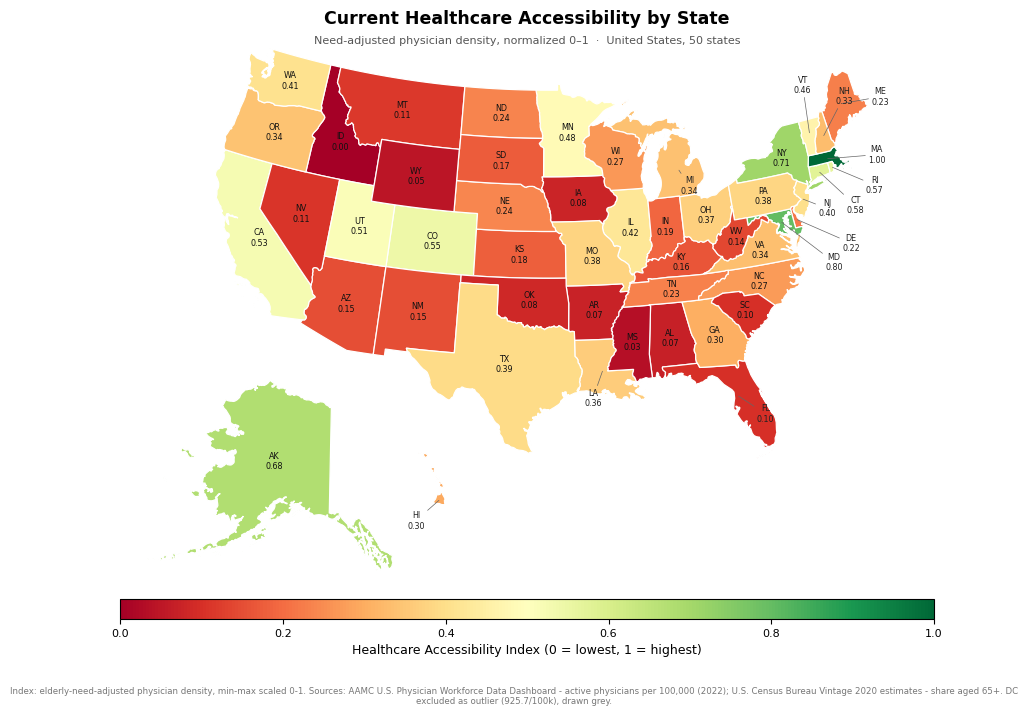

In [7]:
fig, ax = plt.subplots(figsize=(10.5, 7.6))
draw(ax, idx, "Current Healthcare Accessibility by State",
     "Need-adjusted physician density, normalized 0–1  ·  United States, 50 states")
add_cbar(fig, [ax])
fig.text(0.5, 0.005, FOOT, ha="center", fontsize=6.2, color="#777", wrap=True)
fig.savefig("map1_current_accessibility_us.png", dpi=200,
            bbox_inches="tight", facecolor="white")
plt.show()

### Map 2 — Projected with platform (30% gap-closure scenario)

/sessions/vigilant-zealous-ritchie/tmp/ipykernel_9/2960591711.py:13: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  big = max(polys, key=lambda p: abs(np.cross(p[:-1], p[1:]).sum()) / 2 if len(p) > 2 else 0)


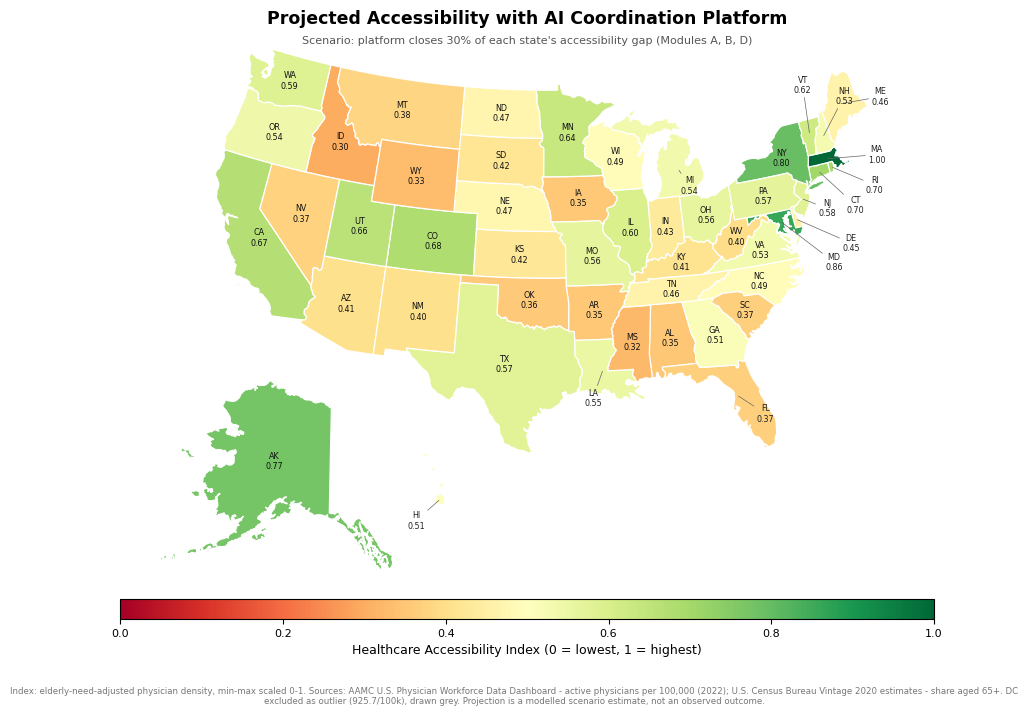

In [8]:
fig, ax = plt.subplots(figsize=(10.5, 7.6))
draw(ax, proj, "Projected Accessibility with AI Coordination Platform",
     "Scenario: platform closes 30% of each state's accessibility gap (Modules A, B, D)")
add_cbar(fig, [ax])
fig.text(0.5, 0.005,
         FOOT + " Projection is a modelled scenario estimate, not an observed outcome.",
         ha="center", fontsize=6.2, color="#777", wrap=True)
fig.savefig("map2_projected_accessibility_us.png", dpi=200,
            bbox_inches="tight", facecolor="white")
plt.show()

### Map 3 — Side-by-side comparison

/sessions/vigilant-zealous-ritchie/tmp/ipykernel_9/2960591711.py:13: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  big = max(polys, key=lambda p: abs(np.cross(p[:-1], p[1:]).sum()) / 2 if len(p) > 2 else 0)


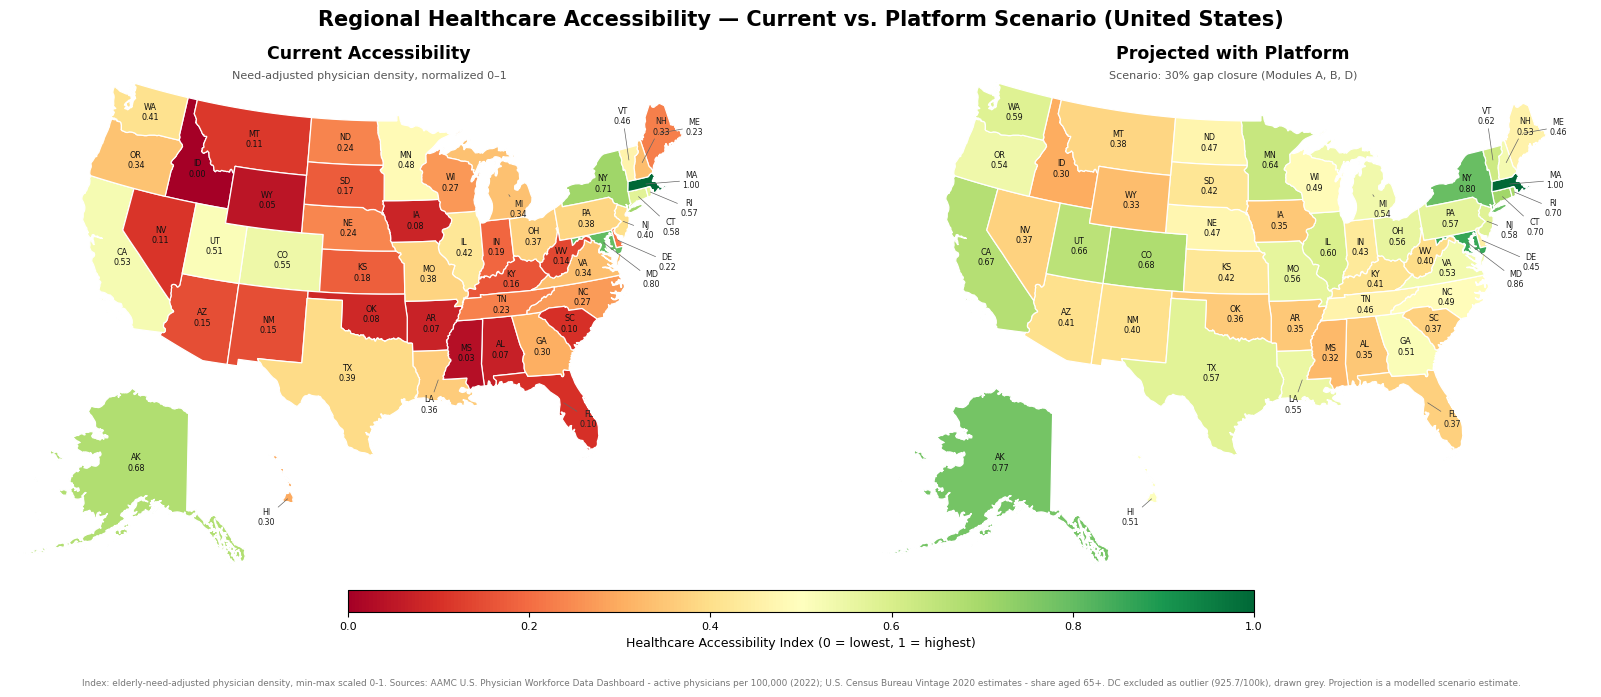

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16.5, 7.0))
fig.subplots_adjust(top=0.88, left=0.02, right=0.98)
draw(axes[0], idx,  "Current Accessibility",
     "Need-adjusted physician density, normalized 0–1")
draw(axes[1], proj, "Projected with Platform",
     "Scenario: 30% gap closure (Modules A, B, D)")
add_cbar(fig, axes)
fig.suptitle("Regional Healthcare Accessibility — Current vs. Platform Scenario (United States)",
             fontsize=15, fontweight="bold", y=0.97)
fig.text(0.5, 0.005, FOOT + " Projection is a modelled scenario estimate.",
         ha="center", fontsize=6.4, color="#777")
fig.savefig("map3_side_by_side_us.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()

## Step 7 — Verification, sensitivity, export

**Checks:** index bounds are exactly [0, 1]; projected ≥ current everywhere with the
largest gains in the reddest states; the extremes match the independent AAMC 2024
cross-check (Massachusetts highest; Idaho/Mississippi lowest), and the bottom group
tracks HRSA rural shortage-area designations.

**Measurement robustness:** although every input is an exact published value, the two
columns come from different vintages (2022 physicians, 2020 aging). We re-run the
pipeline 500 times jittering *all* physician densities by U(−0.1, +0.1) — larger than
any plausible vintage drift — and report how often the bottom-5 set is preserved.

In [10]:
assert abs(df["index_current"].min()) < 1e-9 and abs(df["index_current"].max() - 1) < 1e-9
assert (df["index_projected"] >= df["index_current"] - 1e-9).all()
assert df.sort_values("gain", ascending=False).iloc[0]["region"] == "Idaho"
assert df.sort_values("index_current", ascending=False).iloc[0]["region"] == "Massachusetts"

# Sensitivity 1: rerun the scenario at three gap-closure levels
sens = pd.DataFrame({f"gamma={g:.0%}": df["index_current"] + g * (1 - df["index_current"])
                     for g in (0.15, 0.30, 0.45)})
sens.insert(0, "region", df["region"])
sens.insert(1, "current", df["index_current"])
sens.sort_values("current").round(2).head(15)

,region,current,gamma=15%,gamma=30%,gamma=45%
key,,,,,
id,Idaho,0.00,0.15,0.30,0.45
ms,Mississippi,0.03,0.18,0.32,0.47
wy,Wyoming,0.05,0.19,0.33,0.47
al,Alabama,0.07,0.21,0.35,0.49
ar,Arkansas,0.07,0.21,0.35,0.49
ia,Iowa,0.08,0.21,0.35,0.49
ok,Oklahoma,0.08,0.22,0.36,0.50
sc,South Carolina,0.10,0.23,0.37,0.50
fl,Florida,0.10,0.24,0.37,0.51


In [11]:
# Sensitivity 2: robustness of the bottom-5 ranking to vintage drift in physician data
rng = np.random.default_rng(42)
base_bottom5 = set(df.sort_values("index_current").head(5)["region"])
hits = contained = 0
for _ in range(500):
    d = df["doctors_per_1k"] + rng.uniform(-0.1, 0.1, size=len(df))
    s = d / df["need_ratio"]
    i = (s - s.min()) / (s.max() - s.min())
    ranked = df.assign(i=i).sort_values("i")["region"]
    hits += set(ranked.head(5)) == base_bottom5
    contained += base_bottom5 <= set(ranked.head(8))
print(f"bottom-5 set {sorted(base_bottom5)}")
print(f"exact set preserved in {hits/500:.0%} of 500 perturbed runs "
      f"(Arkansas and Iowa are near-tied at 2.13, so the 5th slot flips)")
print(f"all five contained in the perturbed bottom-8 in {contained/500:.0%} of runs -")
print("the underserved Mountain-West / Deep-South cluster itself is stable.")

bottom-5 set ['Alabama', 'Arkansas', 'Idaho', 'Mississippi', 'Wyoming']
exact set preserved in 15% of 500 perturbed runs (Arkansas and Iowa are near-tied at 2.13, so the 5th slot flips)
all five contained in the perturbed bottom-8 in 79% of runs -
the underserved Mountain-West / Deep-South cluster itself is stable.


In [12]:
out = df[["region", "doctors_per_1k", "pct_65plus",
          "need_adj_supply", "index_current", "index_projected"]].round(3)
out.to_csv("accessibility_index_data_us.csv", index=False)
print("saved: accessibility_index_data_us.csv, map1/2/3 PNGs")

saved: accessibility_index_data_us.csv, map1/2/3 PNGs


## References

1. AAMC (Association of American Medical Colleges), *U.S. Physician Workforce Data
   Dashboard* — active physicians per 100,000 population by state, 2022; full ranking
   as published by Becker's Hospital Review, Nov 20 2023.
   https://www.beckershospitalreview.com/quality/hospital-physician-relationships/active-physicians-per-100-000-people-ranked-by-state/
2. U.S. Census Bureau, *Vintage 2020 Population Estimates* — population aged 65+ by
   state; ranked table via Population Reference Bureau, "Which U.S. States Have the
   Oldest Populations?". https://www.prb.org/news/which-us-states-are-the-oldest/
3. U.S. Census Bureau, *2023 ACS 1-year / 5-year Estimates* (table S0101) — cross-check
   vintage: Maine 22.9% oldest, Utah 12.2% youngest, national 17.7%; via ConsumerAffairs
   compilation. https://www.consumeraffairs.com/homeowners/elderly-population-by-state.html
4. AAMC, *2025 Key Findings* — 2024 cross-check: Massachusetts highest / Idaho &
   Mississippi lowest physicians per capita; national 304 per 100,000.
   https://www.aamc.org/data-reports/data/2025-key-findings
5. Boundary geometry: `@svg-maps/usa` v2.0.0 (MIT).
   https://www.npmjs.com/package/@svg-maps/usa